1. Defining the Predictive Problem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The business in question would like to predict the determining factors of Customer Churn. They seek this knowledge in order to reduce customer churn, retain clients and ultimately increase revenue generated from their current customer base.

Churn is important because it tells us how many clients are leaving and why. This allows the business to strategise against churn and retain their business.

In this case our target variable is churn - Yes/no. Whether or not the client will churn.


2. Understanding The Customer Data

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Tyresej00/telco-dataset/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

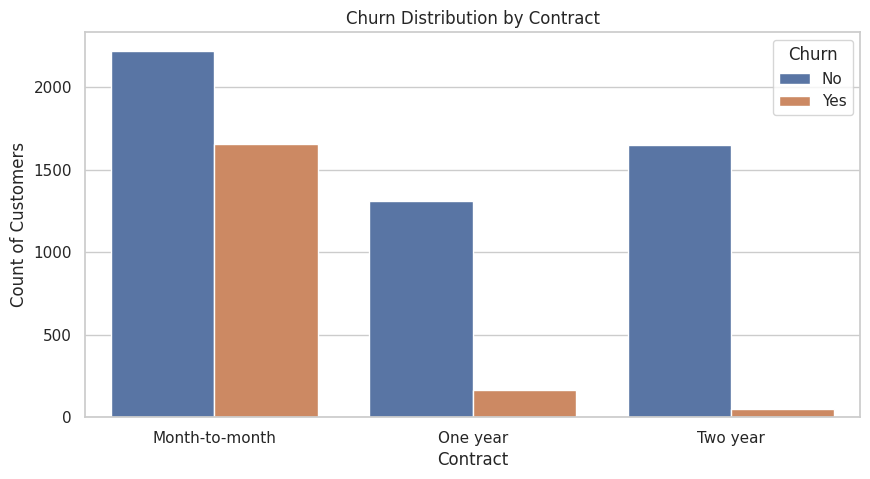

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn Distribution by Contract")
plt.xlabel("Contract")
plt.ylabel("Count of Customers")
plt.show()

Month-month contracts have a signifigantly higher numbers of churn when compared to the longer contracts

Text(0, 0.5, 'Monthly Charges')

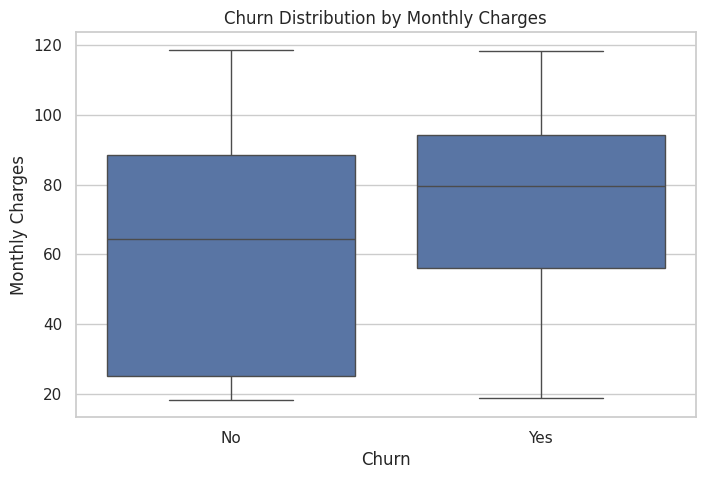

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Churn Distribution by Monthly Charges")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

As presented by the boxplot, there seems to be a correlation between higher monthly charges and customer churn.

Text(0, 0.5, 'Density')

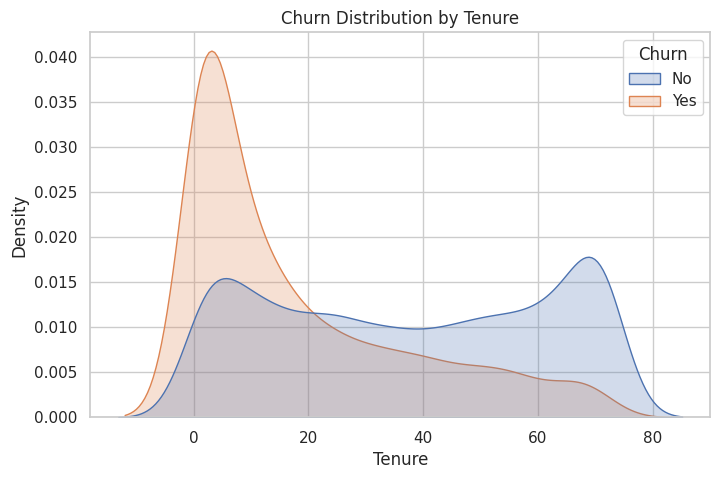

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, common_norm=False)
plt.title("Churn Distribution by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Density")


As we can see, there may be a correlation between tenure and churn, showing that a lower tenure can lead to a higher customer churn probability.


3. Preparing and Cleaning the Data


Handling Missing Values and Categorical Variables

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


TotalCharges is currently an object, however these are numeric values. We will be changing this column data type to numeric so that calculations can be drawn on it.

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
MissingTotalCharge = df[df["TotalCharges"].isnull()]
MissingTotalCharge

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


It's clear that we have missing values, however we should split the data before imputing otherwise this may lead to data leakage.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

We are going to first split the data and then we can impute any missing values with the median of the train set.

In [ ]:
#split the data and determining the target feature

x = df.drop("Churn", axis=1)
y = df["Churn"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

#calculating median from the train set

train_median = x_train["TotalCharges"].median()

#fill in the missing values of both sets

x_train["TotalCharges"] = x_train["TotalCharges"].fillna(train_median)
x_test["TotalCharges"] = x_test["TotalCharges"].fillna(train_median)

#testing if any null values remain

print(x_train["TotalCharges"].isnull().sum())
print(x_test["TotalCharges"].isnull().sum())


0
0


We no longer have missing values in our dataset. We can now proceed to encoding the data using one-hot encoding.

I realised while looking at the data that we kept the customer ID column. This column needs to be removed as it serves no purpose in the model due to it being a unique identifier.

In [ ]:
x_train.drop(columns=['customerID'], axis=1, inplace=True)
x_test.drop(columns=['customerID'], axis=1, inplace=True)

We can now encode our categorical columns

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

categorical_columns = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]
numerical_columns = ["MonthlyCharges", "TotalCharges", "tenure"]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
        ])
x_train_final = preprocessor.fit_transform(x_train)
x_test_final = preprocessor.transform(x_test)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


4. Building the Logistic Regression Model


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_reg = LogisticRegression()

log_reg.fit(x_train_final, y_train_encoded)

LogisticRegression()

5. Understanding Probabilities and Predictions


In [ ]:
y_pred_proba = log_reg.predict_proba(x_test_final)[:, 1]

y_pred = log_reg.predict(x_test_final)

print(y_pred_proba)
print(y_pred)
y_pred_proba.shape

[0.69098937 0.0616343  0.00455654 ... 0.05128153 0.01324009 0.49384327]
[1 0 0 ... 0 0 0]


(1409,)

6. Evaluating Model Performance


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import f1_score

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[934 102]
 [150 223]]


In [ ]:
#F-1 Score
f1 = f1_score(y_test_encoded, y_pred)

print(f"F1-Score: {f1:.4f}")

F1-Score: 0.6390


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
y_pred = log_reg.predict(x_test_final)

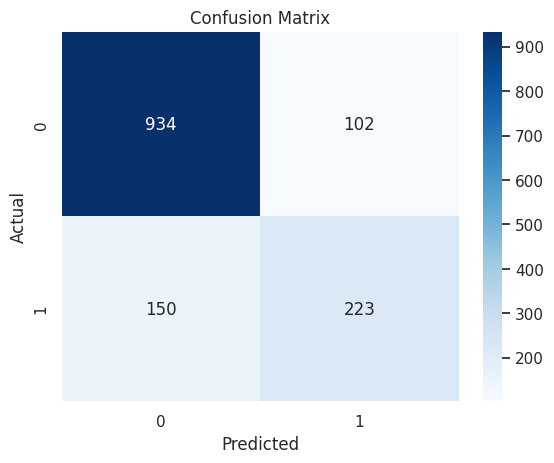

In [ ]:
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [ ]:
feature_names = preprocessor.get_feature_names_out()
coefficients = log_reg.coef_[0]

#DataFrame used to view coefficients clearly
coef_df = pd.DataFrame({'Variable': feature_names, 'Coefficient': coefficients})

#Sort by absolute value to see the most influential features
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print(coef_df)

                                        Variable  Coefficient  Abs_Coefficient
45                                   num__tenure    -1.337605         1.337605
36                        cat__Contract_Two year    -0.826215         0.826215
44                             num__TotalCharges     0.637584         0.637584
34                  cat__Contract_Month-to-month     0.604503         0.604503
13                      cat__InternetService_DSL    -0.555620         0.555620
14              cat__InternetService_Fiber optic     0.533166         0.533166
43                           num__MonthlyCharges    -0.433228         0.433228
37                      cat__PaperlessBilling_No    -0.300153         0.300153
10                         cat__MultipleLines_No    -0.260455         0.260455
15                       cat__InternetService_No    -0.244177         0.244177
20         cat__OnlineBackup_No internet service    -0.244177         0.244177
17       cat__OnlineSecurity_No internet service    